In this ipython notebook, we want to solve the multilevel optimal control problem in discrete time. As example, we choose K = 10, A = [[-1, 2],[0, 1]] and B = [0, 1].

In [1]:
import numpy as np
import random
from tqdm import trange
import matplotlib.pyplot as plt
#np.seterr(all='raise')

We first initialize the technical parameters...

In [2]:
switchingCost = .1 #cost of switching up or down a level
learningRate = .5
gamma = 1
evaluateEvery = 1000
itNumber = 10000 #number of learning iterations
exploreRate = .5 #rate at which exploration happens
learnerType = 'QLEARN' #accepts 'SARSA' or 'QLEARN'

... and the model parameters.

In [3]:
K = 10 #number of time steps

y0 = np.array([3, 1])
ybar = np.array([0, 0])

A = np.array([[-1,2],[0,1]])
B = np.array([0,1])
controlSpace = {-1,-.5,0,.5,1}

To setup a Reinforcement Learning algorithm, we have to define a state space first, which is the set of all possible states the model can be in. In order to enforce a staircase structure and impose switching costs, we add the current level of the model into the state space.

In [4]:
umax = int(np.ceil(max(np.abs(sorted(controlSpace)))))
N = len(y0)
tt = np.linspace(0, K, K+1)

xSpace = np.linspace(y0[0] - K*umax, y0[0] + K*umax, 4*K*umax+1) #calculated manually
ySpace = np.linspace(y0[1] - K*umax, y0[1] + K*umax, 4*K*umax+1)

Now we can define the costs and the state transitions.

In [5]:
def runningCost(state, u):
    (x, a) = state
    return switchingCost*(a!=u)*(a!=None) #+ runningFactor*np.sum((x-ybar)*(x-ybar))

def finalCost(state):
    (x, a) = state
    return np.linalg.norm(x-ybar) #final cost

def transition(state, u):
    (x, a) = state
    yNew = A@x + B*u
    return (yNew, u)

This allows us, given a set of control actions (here referred to as "policy"), to define a model simulator.

In [6]:
def simulator(x0, policy):
    x = np.zeros((N,K+1))
    r = np.zeros(K+1)
    u = np.zeros(K)
    x[:,0] = x0
    state = (x0, None)
    for n in range(K):
        action = policy[n]
        newState = transition(state, action)
        xnew = newState[0]
        rnew = runningCost(state, action)
        x[:,n+1] = xnew
        u[n] = action
        r[n] = rnew
        state = newState
    r[K] = finalCost(state)
    return (x, u, r)

The formulation of the state space allows us to specify which control actions are allowed. This is useful to enforce the staircase structure.

The Q-algorithm needs the so-called Q function, which in our case assigns to a state (m, x, a) (where m is the time, x the state and a the current control level) and an action u the value of that state-action pair. We can just model the Q function as a Python dictionary, where for x we choose the points of the state space. If m=0, there is no currently active control, which is why we add the entries with a=None separately.

In [7]:
def staircase(u):
    if u == None:
        staircaseSet = controlSpace
    else:
        controls = sorted(controlSpace)
        uInd = controls.index(u)
        staircaseSet = {u}
        if uInd > 0:
            staircaseSet.add(controls[uInd-1])
        if uInd < len(controls)-1:
            staircaseSet.add(controls[uInd+1])
    return staircaseSet

def discreteBasis(xSpace, ySpace, controlSpace, K):
    indSet0 = {(m, x, y, a, u) for m in range(1, K) for x in xSpace for y in ySpace for a in controlSpace for u in staircase(a)}
    indSet = indSet0.union({(0, x, y, None, u) for x in xSpace for y in ySpace for u in controlSpace})
    return indSet

Now we are ready to define a RL agent. The functions xInStateSpace and yInStateSpace are necessary because of machine precision errors, but could also be used for a continuous state space as so-called state aggregators.

In [8]:
### Learner
class Learner:
    def __init__(self, learnerType, learningRate, exploreRate, evaluateEvery):
        self.learnerType = learnerType
        self.learningRate = learningRate
        self.exploreRate = exploreRate
        self.evaluateEvery = evaluateEvery
        self.polyBasis = discreteBasis(xSpace, ySpace, controlSpace, K)
        self.theta = {ind:np.random.rand() for ind in self.polyBasis} #initialize the Q function randomly
        self.totalIt = 0
        self.totalDeltaArr = []
        self.totalCostArr = []
        self.totalEvalArr = []
        self.finalEvalArr = []

    def approxQ(self, m, state, u):
        (x, a) = state
        xInStateSpace = min(xSpace, key = lambda t: abs(t-x[0])) #for state aggregation
        yInStateSpace = min(ySpace, key = lambda t: abs(t-x[1]))
        val = self.theta[(m, xInStateSpace, yInStateSpace, a, u)]
        return val

    def greedy(self, m, state):
        (x, a) = state
        umin = min(staircase(a), key = lambda u: self.approxQ(m, state, u))
        return umin

    def findMinQ(self, m, state):
        (x, a) = state
        umin = self.greedy(m, state) #min(staircase(a), key = lambda u: self.approxQ(m, state, u))
        fumin = self.approxQ(m, state, umin)
        return fumin
        
    def Qsimulator(self, x0):
        x = np.zeros((N,K+1))
        r = np.zeros(K+1)
        u = np.zeros(K)
        x[:,0] = x0
        state = (x0, None)
        for n in range(K):
            action = self.greedy(n, state)
            newState = transition(state, action)
            xnew = newState[0]
            rnew = runningCost(state, action)
            x[:,n+1] = xnew
            u[n] = action
            r[n] = rnew
            state = newState
        r[K] = finalCost(state)
        return (x, u, r)
    
    def learn(self, itNumber):
        deltaArr = np.zeros(itNumber)
        for k in trange(itNumber): #trange adds a progress bar
            if (k+self.totalIt) % self.evaluateEvery == 0:
                self.evaulate()

            deltaMax = -np.inf
            state = (y0, None)
            
            totalCost = 0
            for m in range(K): #perform one sweep
                if np.random.random() < self.exploreRate: #Exploration
                    (x, a) = state
                    action = random.sample(sorted(staircase(a)),1)[0]
                else:
                    action = self.greedy(m, state)
                
                newState = transition(state, action)
                
                rnew = runningCost(state, action)
                totalCost += rnew
                
                if m == K-1:
                    totalCost += finalCost(newState)
                    #print(totalCost)
                    delta = rnew + gamma*finalCost(newState) - self.approxQ(m, state, action)
                else:
                    match learnerType: 
                        case 'QLEARN':
                            delta = rnew + gamma*self.findMinQ(m+1, newState) - self.approxQ(m, state, action)
                            deltaMax = max(deltaMax, abs(delta))
                        case 'QTLEARN':
                            delta = [rnew + gamma*self.findMinQ(mm+1, newState) - self.approxQ(mm, state, action) for mm in range(K-1)]
                            deltaMax = max(deltaMax, max(list(map(abs, delta))))
                        case 'SARSA':
                            delta = rnew + gamma*self.approxQ(m+1, newState, action) - self.approxQ(m, state, action)
                            deltaMax = max(deltaMax, abs(delta))
                    #print(delta)
                
                (x, a) = state
                u = action
                
                xInStateSpace = min(xSpace, key = lambda t: abs(t-x[0])) #for state aggregation
                yInStateSpace = min(ySpace, key = lambda t: abs(t-x[1]))
                if not(m == K-1) and learnerType == 'QTLEARN':
                    for mm in range(K-1):
                        self.theta[(mm, xInStateSpace, yInStateSpace, a, u)] += self.learningRate*delta[m]#/np.sqrt(1 + k/20)
                else:
                    self.theta[(m, xInStateSpace, yInStateSpace, a, u)] += self.learningRate*delta#/np.sqrt(1 + k/20)
                state =  newState
            #print('deltaMax =', deltaMax)
            deltaArr[k] = deltaMax
            self.totalCostArr.append(totalCost)
        self.totalIt += itNumber
        self.totalDeltaArr.extend(deltaArr)
    
    def evaulate(self):
        *_, r = self.Qsimulator(y0)
        self.totalEvalArr.append(sum(r))
        self.finalEvalArr.append(r[-1])
    
    def makePictures(self):
        (y, u, r) = self.Qsimulator(y0)

        plt.plot(tt, np.hstack((u,u[-1])), drawstyle='steps-post', label='u') #show learned control
        plt.xlabel('t')
        plt.ylabel('u(t)')
        plt.legend()
        plt.title('Control over time')
        plt.show()

        plt.plot(tt, y[0,:]) #show learned solution
        plt.plot(tt, y[1,:])
        plt.xlabel('k')
        plt.ylabel('x(k)')
        plt.title('Solution over time')
        plt.show()

        #plt.semilogy(self.totalDeltaArr) #show evolution of delta
        #plt.xlabel('iteration')
        #plt.ylabel('deltaMax')
        #plt.show()
        
        #plt.semilogy(self.totalCostArr) #show evolution of the costs during training
        #plt.xlabel('iteration')
        #plt.ylabel('costs per episode')
        #plt.show()

        plt.plot(self.totalEvalArr, label='total') #show evolution of the evaluated costs during training
        plt.plot(self.finalEvalArr, label='final')
        plt.xlabel('iteration')
        plt.ylabel('cost')
        plt.title('Evaluated costs per episode')
        plt.legend()
        plt.show()

        

Initialize and train a first agent:

In [9]:
myQLearner = Learner('QLEARN', learningRate, exploreRate, evaluateEvery)
myQLearner.learn(itNumber)

100%|██████████| 10000/10000 [00:36<00:00, 271.53it/s]


Show the results: the structure of the control the agent has learned, the corresponding optimal solution, and the evolution of the evaluated costs during training. If we set the switching costs to zero, the control still steers the state towards zero, but becomes more erratic.

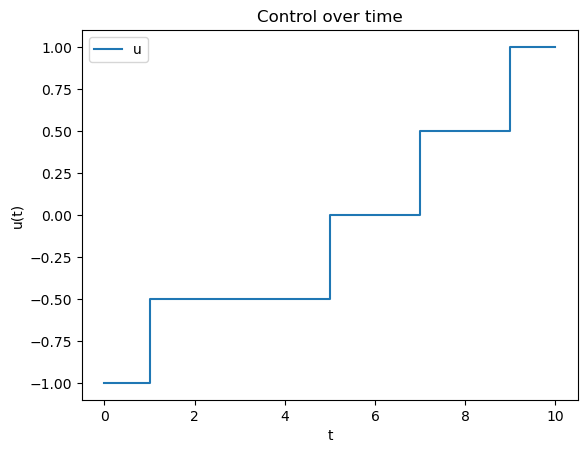

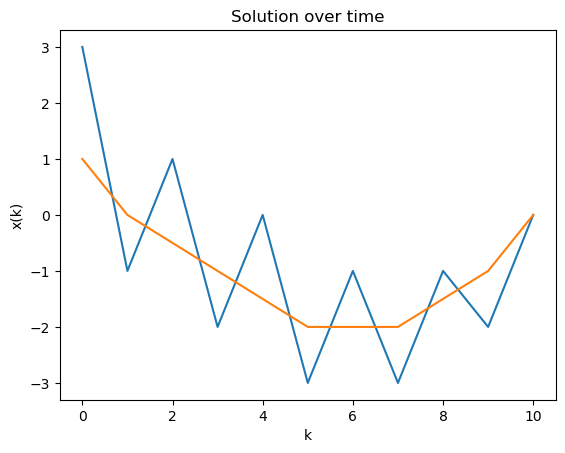

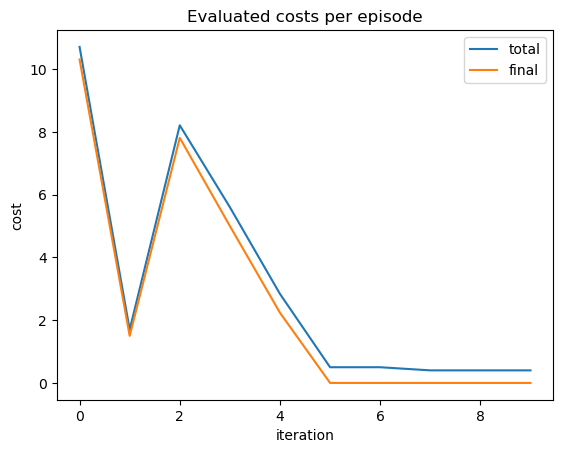

In [10]:
myQLearner.makePictures()

We can also compare with a control policy we came up with ourselves. To check, we note that x(10) = x(0) + [2*(u0+u2+u4+u6+u8), u0+u1+u2+u3+u4+u5+u6+u7+u8+u9] for our particular choices of A and B.

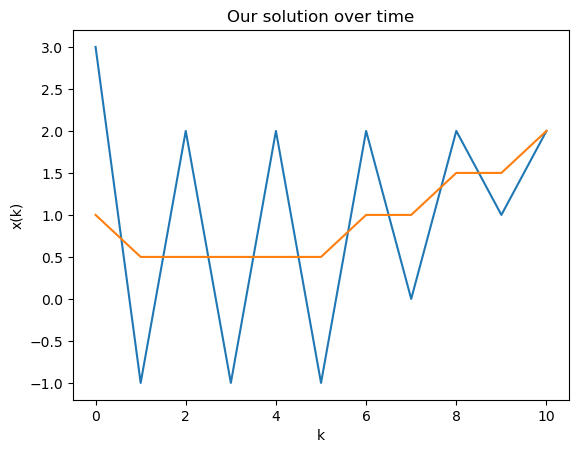

In [11]:
policy = [-.5,0,0,0,0,.5,0,.5,0,.5]
(ypol, upol, rpol) = simulator(y0, policy)
plt.plot(tt, ypol[0,:])
plt.plot(tt, ypol[1,:])
plt.xlabel('k')
plt.ylabel('x(k)')
plt.title('Our solution over time')
plt.show()